### Lab 6 - Data Splitting in Prediction
STAT 450 <br>
TA: Jonathan Agyeman <br>
Feb 16, 2024 <br>

In [78]:
# House-keeping Code
library(tidyverse)
library(broom)
library(tidymodels)
library(glmnet)

We've seen data splitting used in inference in-class. In this lab, we'll see how data-splitting is used in model selection and prediction. 

We want to avoid the model to overfit the training data and perform poorly in the test data. Hence, we separate the available data into training, validation, and testing subsets to prevent the model from overfitting and to obtain a reliable estimate of the out-of-sample error, where we predict observations that the model didn't have access to during the fitting process.

In simple words, the three subsets are defined as follows:
* Training: Set of data used for learning (by the model), that is, to fit the parameters to the model
* Validation: Set of data used to provide an unbiased evaluation of a model fitted on the training dataset while tuning model hyperparameters. It also plays a role in other forms of model preparation, such as feature selection, threshold cut-off selection.
* Testing: Set of data used to provide an unbiased evaluation of a final model fitted on the training dataset.

This splitting should ideally happen even before you've performed any exploratory data analysis.

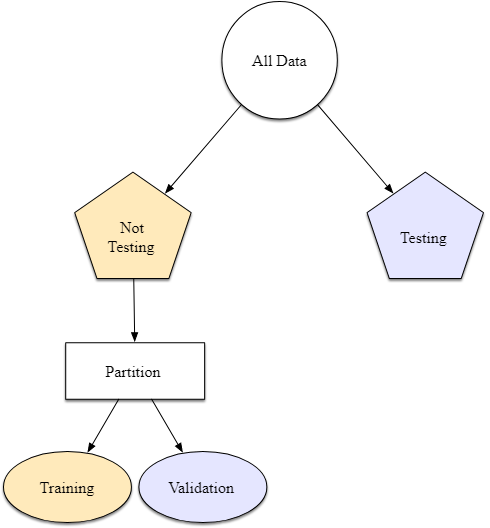 https://www.tidymodels.org/start/case-study/#data-split 

The general steps should be:
1. We use the training set to fit as many models as we want;
2. We compare the out-of-sample models' performance using the validation set;
3. Once we have a winner, we estimate the out-of-sample performance using the test set.


Imagine you have 3 competing models. You want to select the one with the best prediction accuracy. How would you do that?
Let's consider applying this to some simulated data. We'll compare the data splitting method to the following two approaches:

##### Approach 1

1. We use the training set to fit the models.
2. We select the model with the best prediction accuracy in the training set.
3. We test the model in the test set to obtain an estimate of the out-of-sample error of the selected model.

Canvas: What is wrong with this approach? Overfitting? double-dipping?

##### Approach 2

1. We use the training set to fit the models;
2. We assess each model prediction accuracy in the test set;
3. The most accurate model in the test set wins. 

Canvas: What is wrong with this approach? Overfitting? Double-dipping?

In [79]:
# Run this cell before continuing 
set.seed(20230217)

n <- 60    # sample size
p <- 10     # number of variables
rep <- 100 # number of replications

means <- runif((p), 3, 10) # the mean that will be used in the 
                             # Normal distribution for simulation.
                              

dataset <- as_tibble(
  data.frame(
    matrix(
      round(rnorm((p) * n * rep, 
            means, sd=0.2), 2), 
      ncol = p, 
      byrow = TRUE
    )
  ) %>% 
  mutate(Y = 5 +  8 * X1 + 5 * X2 + 7 * X3 + 8 * X4 + X1^2 + rnorm(n*rep, sd = 5)) %>% # expected MSPE should be 25
  mutate(replicate = rep(1:rep, n)) %>% 
  arrange(replicate) 
)

head(dataset)


X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y,replicate
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2.99,6.66,9.19,8.38,8.67,6.57,8.79,10.01,7.34,4.50,206.2093,1
3.20,7.35,9.36,8.28,9.09,6.67,8.50,9.87,7.06,4.32,216.9099,1
2.93,6.27,9.57,8.88,8.81,6.31,8.26,9.59,7.70,4.32,213.5259,1
3.31,6.98,9.60,8.98,8.95,6.54,8.83,9.85,7.39,4.44,212.5854,1
3.10,6.75,9.02,8.24,8.62,6.15,8.31,9.92,6.99,4.45,204.2241,1
2.67,7.15,9.16,8.54,8.54,6.61,8.56,9.66,7.34,4.56,200.4583,1


In [80]:
# reference: https://stackoverflow.com/questions/36068963/r-how-to-split-a-data-frame-into-training-validation-and-test-sets
set.seed(20230217)
spec = c(train = .5, test = .25, validate = .25)
MSPEs = data.frame(best_approach= numeric(rep),
                    approach1 = numeric(rep),
                    approach2 = numeric(rep))
model_tracking = data.frame(validation_approach= character(rep),
                    approach1 = character(rep),
                    approach2 = character(rep)) # keep track of which model was selected

newdata_MSPEs = data.frame(best_approach= numeric(rep),
                    approach1 = numeric(rep),
                    approach2 = numeric(rep))                  

for (i in c(1:rep)){
  one_replicate <- dataset %>% filter(replicate == i) %>% select(-replicate)
  g = sample(cut(
  seq(nrow(one_replicate)), 
  nrow(one_replicate)*cumsum(c(0,spec)),
  labels = names(spec)
  ))
  df = split(one_replicate, g)

  model1 = lm(Y ~ X1 + X2 + X3 + X4 + X1^2, df$train)
  model2 = lm(Y ~ X1 + X1^2 + X1^3 + X1^4 + X1^5, df$train)
  model3 = lm(Y ~ ., df$train)
  model_list = list(model1 = model1, model2 =  model2, model3 = model3)

  ## Best approach: train. validation, test set approach
  validation_MSPE = c(mean((df$validate$Y - predict.lm(model1, df$validate)) ^ 2),
    mean((df$validate$Y - predict.lm(model2, df$validate)) ^ 2),
    mean((df$validate$Y - predict.lm(model3, df$validate)) ^ 2)
    )
    ### out of sample MSPE
  MSPEs[i,1] = mean((df$test$Y - predict.lm(model_list[[which.min(validation_MSPE)]], df$test)) ^ 2)
  model_tracking[i,1]= case_when(which.min(validation_MSPE) == 1 ~ "model1", 
                                which.min(validation_MSPE) == 2 ~ "model2",
                                which.min(validation_MSPE) == 3 ~ "model3")

  ## Approach 1

  ap1_train_MSPE = c(mean((df$train$Y - predict.lm(model1, df$train)) ^ 2),
  mean((df$train$Y - predict.lm(model2, df$train)) ^ 2),
  mean((df$train$Y - predict.lm(model3, df$train)) ^ 2)
  )
  MSPEs[i,2] = mean((c(df$test$Y, df$validate$Y) - predict.lm(model_list[[which.min(ap1_train_MSPE)]], rbind(df$test, df$validate))) ^ 2)
  model_tracking[i,2]= case_when(which.min(ap1_train_MSPE) == 1 ~ "model1", 
                                which.min(ap1_train_MSPE) == 2 ~ "model2",
                                which.min(ap1_train_MSPE) == 3 ~ "model3")
  
  ## Approach 2
  ap2_test_MSPE= c(
  mean((c(df$test$Y, df$validate$Y) - predict.lm(model1, rbind(df$test, df$validate))) ^ 2),
  mean((c(df$test$Y, df$validate$Y) - predict.lm(model2, rbind(df$test, df$validate))) ^ 2),
  mean((c(df$test$Y, df$validate$Y) - predict.lm(model3, rbind(df$test, df$validate))) ^ 2)
  )
  MSPEs[i,3] = min(ap2_test_MSPE)
  model_tracking[i,3]= case_when(which.min(ap2_test_MSPE) == 1 ~ "model1", 
                                which.min(ap2_test_MSPE) == 2 ~ "model2",
                                which.min(ap2_test_MSPE) == 3 ~ "model3")

}

Since we simulated the error term in generating the outcome Y, we expect it to be a close to 100. Now let's take look at the mean of the "out-of-sample" MSPE in all three approaches. 

In [81]:
colMeans(MSPEs)
model_tracking %>%  mutate_if(is.character,as.factor) %>% summary()

best_approach     approach1     approach2 
     30.89854      38.65808      28.01758

 validation_approach  approach1    approach2 
 model1:54           model3:100   model1:61  
 model2:32                        model2:28  
 model3:14                        model3:11  

Approach 1 overestimates the MSPE more than other methods. Furthermore, it runs the risk of always choosing the full model. 

Approach 2 has a lower "out-of-sample" MSPE, but that doesn't mean it's better. Approach 2 has some flaws too - we chose the model with the lowest MSPE in the test set and also used the MSPE to represent the out-of-sample MSPE. This is considered double-dipping into the data. It underestimates the true out-of-sample MSPE because it 'by chance' chooses the model that gives the lowest MSPE and uses it as a proxy of the real MSPE. When given an actual new dataset to predict, it will under-perform compared to the model selected based on the validation set. 


### The Problem of Double Dipping

>A modeling procedure that closely matches every nuance of the data (i.e., overfitting) will have high accuracy for the original dataset to which it is applied but will fail to replicate in new datasets. In contrast, an overly general model (i.e., underfitting) may perform consistently across datasets yet provide low accuracy and thus low utility. Double dipping is a term for overfitting a model through both building and evaluating the model on the same data-set, yielding inappropriately high statistical significance and circular logic.
>
>Making predictions involves two steps. The first step is to determine which variables to use in predicting the outcome (i.e., feature selection). The second step is to assess how accurately a model predicts the outcome (i.e., model evaluation). Double dipping occurs when features are selected using the same criteria, and in the same sample, as model evaluation. In other words, if one first searches for predictor variables that relate to the outcome within a sample of subjects, and then builds a predictive model containing only those variables, the model will unavoidably demonstrate high accuracy in that sample. This accuracy may be based on chance relationships specific to the sample, and such a double-dipped model will therefore be highly biased, consistently overestimating how the model will perform outside the specific sample \.

Ball TM, Squeglia LM, Tapert SF, Paulus MP. Double Dipping in Machine Learning: Problems and Solutions. Biol Psychiatry Cogn Neurosci Neuroimaging. 2020 Mar;5(3):261-263. doi: 10.1016/j.bpsc.2019.09.003. Epub 2019 Sep 16. PMID: 31678119; PMCID: PMC7422774.

### Apply `tidymodels` on Data Splitting and LASSO

Let's see how data-splitting can be done in a workflow. The `tidymodels` package is a collection of packages for modeling and machine learning using tidyverse principles. Below is a toy example to get a taste of it. If you're interested in learning more, feel free to check out https://www.tidymodels.org/.  

[1] 5.361198

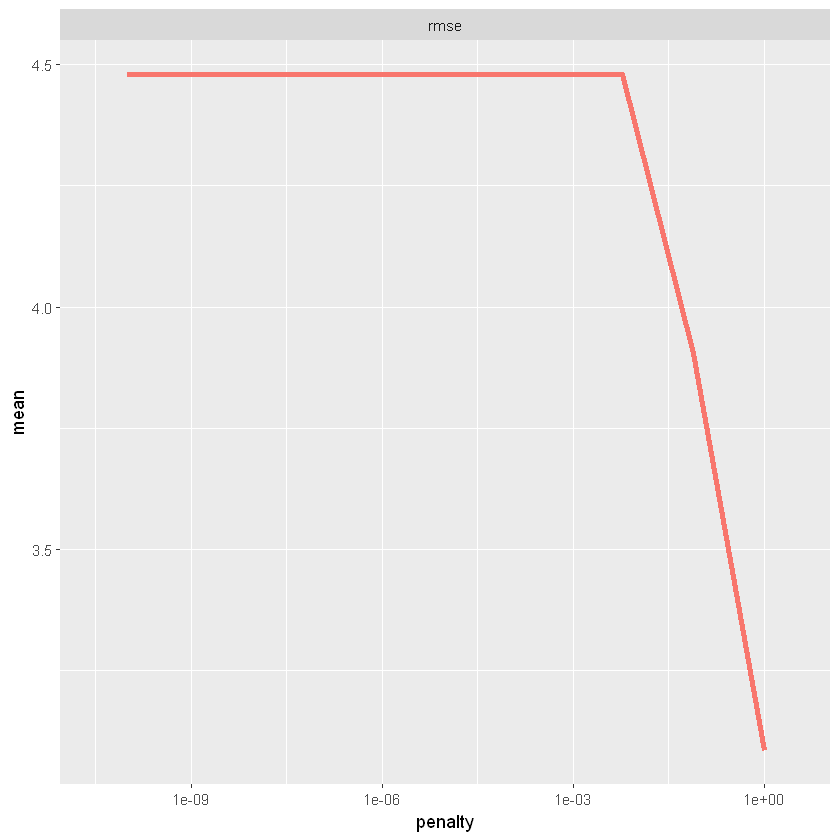

In [82]:
# https://www.tidymodels.org/start/case-study/#data-split
set.seed(20230217)
df = dataset %>% filter(replicate == 1) %>% select(-replicate)
splits      <- initial_split(df, prop = 0.5)
train <- training(splits)
test  <- testing(splits)

val_set <- validation_split(train, 
                            prop = 0.80)

lasso <- linear_reg(penalty = tune(), mixture = 1) %>%
  set_engine("glmnet")

reg_grid <- grid_regular(penalty(), levels = 10)

recipe <- recipe(Y ~ ., data = train)

wf <- workflow() %>%
  add_model(lasso) %>% 
  add_recipe(recipe)

lr_res <- 
  wf %>% 
  tune_grid(val_set,
            grid = reg_grid,
            control = control_grid(save_pred = TRUE),
            metrics = metric_set(rmse))

# plot rmse
lr_res %>%
  collect_metrics() %>%
  ggplot(aes(penalty, mean, color = .metric)) +
  geom_errorbar(aes(
    ymin = mean - std_err,
    ymax = mean + std_err
  ),
  alpha = 0.5
  ) +
  geom_line(size = 1.5) +
  facet_wrap(~.metric, scales = "free", nrow = 2) +
  scale_x_log10() +
  theme(legend.position = "none")

# 
lowest_rmse <- lr_res %>%
  select_best("rmse")

final_fitted <- finalize_workflow(wf, lowest_rmse) %>%
    fit(data = train)

prediction = predict(final_fitted, test) %>% select('.pred') %>% pull()

sqrt(mean((test$Y -prediction)^2)) # close to 5, not bad!

### Other Cases for Data Splitting for Prediction
* K-fold cross-validation when there is limited data: evaluates the model on the full variety of the dataset to derive an average model result that will more accurately estimate the model performance than evaluating on just a small test data
    * Train model using k -1 folds
    * Validate model on the remaining fold that was not used for training
    * Repeat above two steps for each combination of folds and average the model results
* Splitting a time series data
    * One way is to ensure that the test data is chronologically later than the training data
    * A more complicated way is to use a walk-forward validation
    
    ![Walk-forward Validation](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*lmUY2pKwxu5kwA1II6yAbQ.png) https://towardsdatascience.com/data-splitting-for-model-evaluation-d9545cd04a99


   References:
   * https://towardsdatascience.com/data-splitting-for-model-evaluation-d9545cd04a99
   * https://audhiaprilliant.medium.com/walk-forward-optimization-cross-validation-technique-for-time-series-data-61739f58f2c0 
   * https://www.tidymodels.org/start/case-study/#data-split
